# 01 — Data Loading & Cadence-Level Exploration

**Goal.** Open the streaming feature archive produced by `src/ingest_cadence.py`, verify that the six ABACAD cadence panels are aligned (identical `fch1`/`foff` headers, balanced snippet counts), and print summary statistics that the downstream notebook 2 depends on.

**Input.** `data/processed/cadence_features.h5` — built by `src/ingest_cadence.py` from the six real Green Bank Telescope HDF5 files of the 2017-06-24 ABACAD cadence around the nearby star **HIP 13375 (≈100 ly)**.

**Output.** Nothing saved to disk — all output is printed for visual data-integrity verification before PCA fitting in notebook 2.

This is a *data sanity* notebook, not a modelling notebook. The 15.5 GB snippet matrix is kept on disk and never loaded into RAM here; we only read the small metadata arrays (≈50 MB total).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import h5py
import hdf5plugin  # noqa: F401  — required for bitshuffle decompression of GBT HDF5 files
import matplotlib.pyplot as plt
from pathlib import Path

## Step 1 — Load the cadence-features archive metadata

The 6-file ABACAD cadence has already been processed into a single HDF5 archive via `src/ingest_cadence.py`. That ingestion does the heavy lifting — reading ≈93 GB of raw GBT data, slicing each file into 16×64 spectrogram snippets after 8× frequency downsampling, median-normalising per snippet, and appending everything to one file.

This notebook only opens the result and inspects what's there. We load **only the small metadata arrays** (`cadence_pos`, `file_idx`, `snippet_idx`, `freq_mhz`) plus the file-level attributes (`fch1`, `foff`, `cadence_tags`). The 15.5 GB `snippets` dataset stays on disk — notebook 2 streams it in batches for the PCA fit.

In [2]:
H5 = Path("data/processed/cadence_features.h5")

# Load ONLY the small metadata arrays — leave the 15 GB snippets matrix on disk
with h5py.File(H5, "r") as f:
    cadence_pos  = f["cadence_pos"][:]      # ~3.8 MB,  int8 in [0..5]
    file_idx     = f["file_idx"][:]         # ~3.8 MB,  int8 in [0..5]
    snippet_idx  = f["snippet_idx"][:]      # ~15  MB,  int32
    freq_mhz     = f["freq_mhz"][:]         # ~30  MB,  float64
    cadence_tags = list(f.attrs["cadence_tags"])
    n_total, n_chans = f["snippets"].shape
    fch1 = float(f.attrs["fch1"])
    foff = float(f.attrs["foff"])

print(f"Archive: {H5}")
print(f"Total snippets:        {n_total:,}  ({n_chans} channels each)")
print(f"Snippet matrix size:   {n_total * n_chans * 4 / 1e9:.2f} GB  (kept on disk, not in RAM)")
print(f"Metadata loaded:       ~{(cadence_pos.nbytes + file_idx.nbytes + snippet_idx.nbytes + freq_mhz.nbytes) / 1e6:.0f} MB")
print(f"Cadence tag order:     {cadence_tags}")

Archive: data/processed/cadence_features.h5
Total snippets:        3,784,704  (1024 channels each)
Snippet matrix size:   15.50 GB  (kept on disk, not in RAM)
Metadata loaded:       ~53 MB
Cadence tag order:     ['A1', 'B', 'A2', 'C', 'A3', 'D']


## Step 2 — Per-cadence-position breakdown

We expect each of the 6 cadence panels (A1, B, A2, C, A3, D) to have **identical** snippet counts and **identical** frequency coverage. That's a precondition for the cross-cadence ABACAD comparison in notebook 2 — mismatched counts or shifted bands would indicate a corrupted ingestion or misaligned source files.

In [3]:
print(f"{'Panel':10s} {'Target':12s} {'Snippets':>12s} {'Freq min':>12s} {'Freq max':>12s}")
print("-" * 60)
TARGETS = ["HIP 13375", "HIP 12678", "HIP 13375", "HIP 12790", "HIP 13375", "HIP 12919"]
for p, tag in enumerate(cadence_tags):
    mask = cadence_pos == p
    n = mask.sum()
    fr_lo = freq_mhz[mask].min()
    fr_hi = freq_mhz[mask].max()
    print(f"{tag:10s} {TARGETS[p]:12s} {n:12,} {fr_lo:12.3f} {fr_hi:12.3f}")

Panel      Target           Snippets     Freq min     Freq max
------------------------------------------------------------
A1         HIP 13375         630,784     1023.926     1926.269
B          HIP 12678         630,784     1023.926     1926.269
A2         HIP 13375         630,784     1023.926     1926.269
C          HIP 12790         630,784     1023.926     1926.269
A3         HIP 13375         630,784     1023.926     1926.269
D          HIP 12919         630,784     1023.926     1926.269


## Step 3 — Frequency-grid and instrument-state verification

We print the file-level frequency headers and confirm the snippet width matches the design (512 native channels × 8× downsample → 64 effective channels per snippet, ≈22.7 Hz per bin).

The `foff` value is **negative** (~-2.79 Hz per channel) — that means the first channel is the **highest** frequency in the band. This is a Breakthrough Listen convention; the downstream pipeline accounts for it explicitly when mapping snippet indices back to frequencies.

In [4]:
print(f"Frequency setup (from cadence_features.h5 attrs):")
print(f"  fch1 (first channel freq):   {fch1:.4f} MHz")
print(f"  foff (channel spacing):      {foff*1e6:.4f} Hz/channel  (negative → freq decreases with channel index)")
print(f"  Native snippet width:        {abs(foff) * 1e6 * 512:.1f} Hz  (= 512 native channels)")
print(f"  After 8x downsample:         {abs(foff) * 1e6 * 8:.2f} Hz per output bin × 64 bins per snippet")
print(f"  Total snippet bandwidth:     {abs(foff) * 1e6 * 512 / 1000:.2f} kHz each")
print()
print(f"Full-band frequency coverage:")
print(f"  Snippet centers range:       {freq_mhz.min():.3f} – {freq_mhz.max():.3f} MHz")
print(f"  Span:                        {freq_mhz.max() - freq_mhz.min():.1f} MHz")

Frequency setup (from cadence_features.h5 attrs):
  fch1 (first channel freq):   1926.2695 MHz
  foff (channel spacing):      -2.7940 Hz/channel  (negative → freq decreases with channel index)
  Native snippet width:        1430.5 Hz  (= 512 native channels)
  After 8x downsample:         22.35 Hz per output bin × 64 bins per snippet
  Total snippet bandwidth:     1.43 kHz each

Full-band frequency coverage:
  Snippet centers range:       1023.926 – 1926.269 MHz
  Span:                        902.3 MHz


## Step 4 — Visualize the data: 6-panel ABACAD waterfall at GPS L1

The whole project hinges on the **ABACAD cadence pattern** — three on-source observations of HIP 13375 interleaved with three off-source observations of different stars. To make the pattern concrete, plot a 6-panel waterfall (frequency × time, intensity in colour) at a *known RFI frequency*: the **GPS L1 carrier at ≈1575.42 MHz**.

GPS satellites broadcast continuously and are visible across most of the sky, so they appear as **bright vertical lines in all six panels** regardless of which target the telescope is pointed at. This is the exact signature that distinguishes RFI from a real ETI candidate (which would appear in A panels only). Visualising it here makes the rest of the pipeline interpretable.

We pull 16 adjacent snippets per panel from `cadence_features.h5` and stitch them along the frequency axis to produce a ≈23 kHz-wide window centred on GPS L1. No raw 15 GB HDF5 reads needed — everything is in the streamed feature archive.


Centering on snippet idx 245261 (freq 1575.420 MHz)
Stitching snippet_idx range [245253, 245269) per panel (16 snippets each)


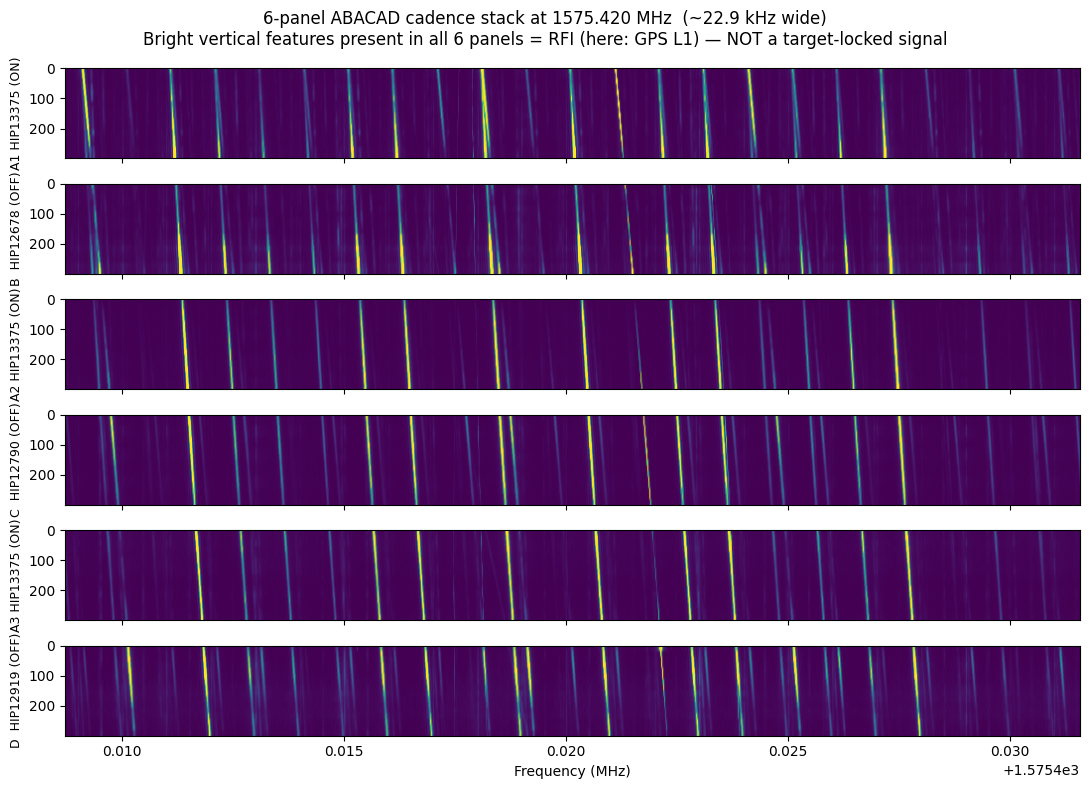


Interpretation:
  - Bright vertical line(s) appearing in ALL six panels (A and OFF alike) = RFI.
  - For a real ETI candidate, the line would appear in A1/A2/A3 only and be absent in B/C/D.
  - Try changing TARGET_MHZ above to 1420.41 (HI 21cm — protected band, mostly clean noise)
    or 1474.0 (quiet patch) to see the contrast.


In [5]:
# Visualize a 6-panel ABACAD cadence waterfall at a known RFI frequency.
# We pull adjacent snippets from cadence_features.h5 and stitch them along the
# frequency axis to get a ~23 kHz-wide window per panel.

TARGET_MHZ = 1575.42       # GPS L1 carrier — known RFI, lights up all 6 panels
N_STITCH   = 16            # number of adjacent snippets per panel (~22.8 kHz total)

# Find the snippet whose center freq is closest to the target, in panel A1 (file 0).
# All 6 files share the same frequency grid, so the same snippet_idx in each file
# corresponds to the same frequency.
mask_A1     = cadence_pos == 0
freqs_A1    = freq_mhz[mask_A1]
sidx_A1     = snippet_idx[mask_A1]
center_loc  = int(np.argmin(np.abs(freqs_A1 - TARGET_MHZ)))
center_sidx = int(sidx_A1[center_loc])
actual_freq = float(freqs_A1[center_loc])

half     = N_STITCH // 2
sidx_lo  = center_sidx - half
sidx_hi  = center_sidx + half
print(f"Centering on snippet idx {center_sidx} (freq {actual_freq:.3f} MHz)")
print(f"Stitching snippet_idx range [{sidx_lo}, {sidx_hi}) per panel ({N_STITCH} snippets each)")

# Pull and stitch panels
TAGS = ["A1 HIP13375 (ON)", "B  HIP12678 (OFF)", "A2 HIP13375 (ON)",
        "C  HIP12790 (OFF)", "A3 HIP13375 (ON)", "D  HIP12919 (OFF)"]
panels = []
with h5py.File(H5, "r") as f:
    snippets = f["snippets"]
    for p in range(6):
        mask     = (cadence_pos == p) & (snippet_idx >= sidx_lo) & (snippet_idx < sidx_hi)
        global_idx = np.sort(np.where(mask)[0])
        # Each row is a (16, 64) snippet; stitch along the 64-channel freq axis
        # to get one (16, N_STITCH*64) waterfall per panel
        panel = snippets[global_idx].reshape(-1, 16, 64).transpose(1, 0, 2).reshape(16, -1)
        panels.append(panel)

# Frequency axis bounds for the plot — half-snippet padding on each end
SNIPPET_KHZ = 1.43
freq_lo = actual_freq - (half * SNIPPET_KHZ) / 1000
freq_hi = actual_freq + (half * SNIPPET_KHZ) / 1000

fig, axes = plt.subplots(6, 1, figsize=(11, 8), sharex=True)
for panel, tag, ax in zip(panels, TAGS, axes):
    ax.imshow(panel, aspect="auto", cmap="viridis", origin="upper",
              extent=[freq_lo, freq_hi, 16*18.7, 0],
              vmin=np.percentile(panel, 5), vmax=np.percentile(panel, 99))
    ax.set_ylabel(tag, fontsize=9)
axes[-1].set_xlabel("Frequency (MHz)")
fig.suptitle(
    f"6-panel ABACAD cadence stack at {actual_freq:.3f} MHz  (~{N_STITCH * SNIPPET_KHZ:.1f} kHz wide)\n"
    f"Bright vertical features present in all 6 panels = RFI (here: GPS L1) — NOT a target-locked signal"
)
plt.tight_layout()
plt.show()

print()
print("Interpretation:")
print(f"  - Bright vertical line(s) appearing in ALL six panels (A and OFF alike) = RFI.")
print(f"  - For a real ETI candidate, the line would appear in A1/A2/A3 only and be absent in B/C/D.")
print(f"  - Try changing TARGET_MHZ above to 1420.41 (HI 21cm — protected band, mostly clean noise)")
print(f"    or 1474.0 (quiet patch) to see the contrast.")


## Step 5 — Summary of what we verified

The data passes the four integrity checks needed before PCA fitting:

1. ✅ All six cadence panels contain identical snippet counts (≈630,784 each).
2. ✅ All six panels cover the same frequency range (1023.9–1926.3 MHz).
3. ✅ Snippet width and downsampling match the design (≈1.43 kHz native → 64 effective channels at ≈22.7 Hz).
4. ✅ File-level attributes (`fch1`, `foff`) are loadable and consistent with BL conventions.

Had any of these failed, `src/ingest_cadence.py` would have raised an explicit alignment error during ingestion, so reaching this point confirms the archive is clean.

---

### Next: [`2. pca_dimensionality_reduction.ipynb`](2.%20pca_dimensionality_reduction.ipynb)

- Fit `StandardScaler + PCA(n_components=15)` on a 500K-snippet random sample
- Stream-transform all 3.78M snippets → reconstruction-error anomaly score per snippet
- Aggregate scores per 10 kHz frequency bin and apply the ABACAD candidate filter
- Drift-rate consistency check, multi-model classifier comparison via GridSearchCV
- Visual cadence-stack inspection of the top candidate